In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Hybrid_Deficit_Condition.csv to Hybrid_Deficit_Condition.csv


In [ ]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.head()


,Time (s),Motor_Power_Demand (kW),Battery_Power (kW),FuelCell_Power (kW),Battery_SOC (%),Battery_Voltage (V),Battery_Current (A),FuelCell_Voltage (V),Vehicle_Speed (km/h),Acceleration
0,0,16.504693,-3.495307,20.0,80.000000,545.682532,-6.405385,799.687965,10.460962,5.637106
1,1,16.319991,-3.680009,20.0,80.003680,550.090084,-6.689830,804.726303,16.098068,4.135478
2,2,23.906150,3.906150,20.0,79.999774,543.165708,7.191451,805.925673,18.731919,7.270095
3,3,20.969549,0.969549,20.0,79.998804,536.478042,1.807249,793.701154,30.638258,2.825210
4,4,27.507669,7.507669,20.0,79.991297,547.558631,13.711169,806.333268,24.382339,-7.658250


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.head()


,Time (s),Motor_Power_Demand (kW),Battery_Power (kW),FuelCell_Power (kW),Battery_SOC (%),Battery_Voltage (V),Battery_Current (A),FuelCell_Voltage (V),Vehicle_Speed (km/h),Acceleration
0,0,16.504693,-3.495307,20.0,80.000000,545.682532,-6.405385,799.687965,10.460962,5.637106
1,1,16.319991,-3.680009,20.0,80.003680,550.090084,-6.689830,804.726303,16.098068,4.135478
2,2,23.906150,3.906150,20.0,79.999774,543.165708,7.191451,805.925673,18.731919,7.270095
3,3,20.969549,0.969549,20.0,79.998804,536.478042,1.807249,793.701154,30.638258,2.825210
4,4,27.507669,7.507669,20.0,79.991297,547.558631,13.711169,806.333268,24.382339,-7.658250


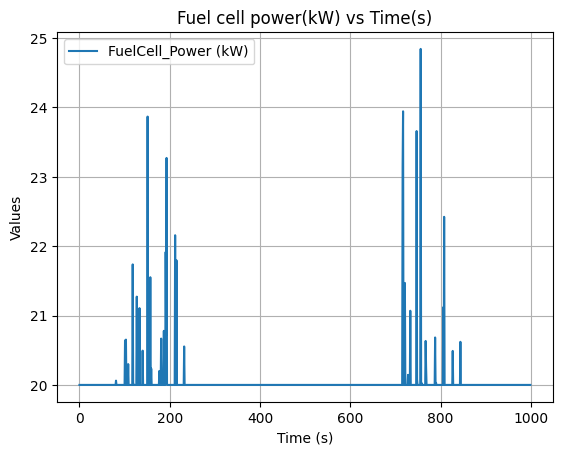

In [ ]:
reference = "Time (s)"   # change if needed
columns_to_plot = [

    "FuelCell_Power (kW)"
]
plt.figure()

for col in columns_to_plot:
    if col in df.columns:
        plt.plot(df[reference], df[col], label=col)

plt.xlabel(reference)
plt.ylabel("Fuel cell power (kW)")
plt.title("Fuel cell power(kW) vs Time(s)")
plt.legend()
plt.grid(True)

plt.show()


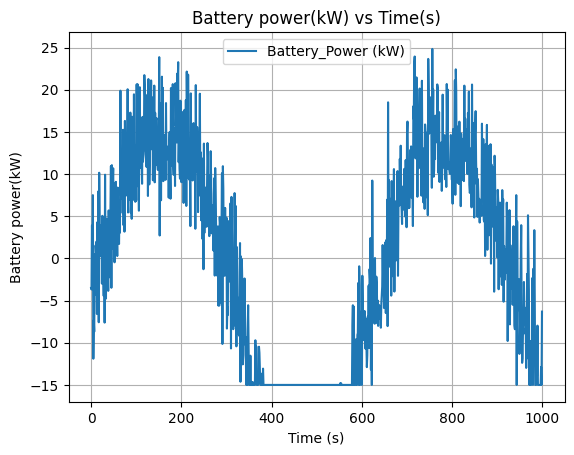

In [ ]:
reference = "Time (s)"   # change if needed
columns_to_plot = [

    "Battery_Power (kW)"
]
plt.figure()

for col in columns_to_plot:
    if col in df.columns:
        plt.plot(df[reference], df[col], label=col)

plt.xlabel(reference)
plt.ylabel("Battery power(kW)")
plt.title("Battery power(kW) vs Time(s)")
plt.legend()
plt.grid(True)

plt.show()


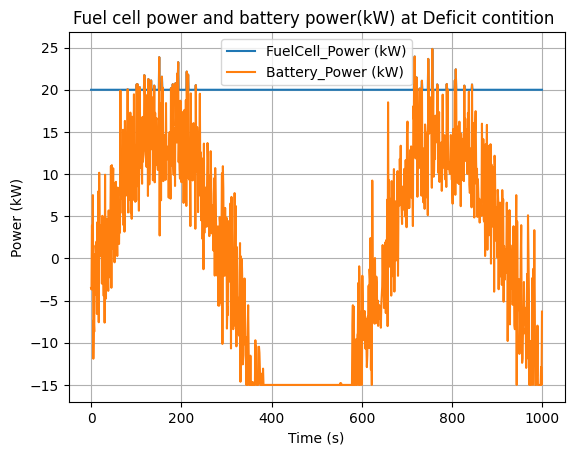

In [ ]:
reference = "Time (s)"   # change if needed
columns_to_plot = [

    "FuelCell_Power (kW)","Battery_Power (kW)"
]
plt.figure()

for col in columns_to_plot:
    if col in df.columns:
        plt.plot(df[reference], df[col], label=col)

plt.xlabel(reference)
plt.ylabel("Power (kW)")
plt.title("Fuel cell power and battery power(kW) at Deficit contition ")
plt.legend()
plt.grid(True)

plt.show()


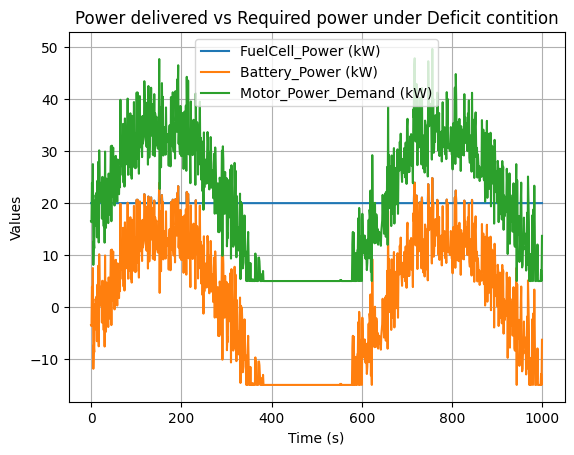

In [ ]:
reference = "Time (s)"   # change if needed
columns_to_plot = [

    "FuelCell_Power (kW)","Battery_Power (kW)","Motor_Power_Demand (kW)"
]
plt.figure()

for col in columns_to_plot:
    if col in df.columns:
        plt.plot(df[reference], df[col], label=col)

plt.xlabel(reference)
plt.ylabel("Values")
plt.title("Power delivered vs Required power under Deficit contition")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset (change file name accordingly)
df = pd.read_csv("your_dataset.csv")

# Display basic info
print(df.head())
print(df.info())

# -------------------------------
# 1. DATA CLEANING
# -------------------------------

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values (if any)
df = df.fillna(method='ffill')

# -------------------------------
# 2. FEATURE ENGINEERING
# -------------------------------

# Example features (modify column names based on your dataset)
# Assume columns: Load, FuelCell, Battery, SOC

# Power difference (important feature)
df['Power_Diff'] = df['Load'] - df['FuelCell']

# Mode labeling
df['Mode'] = df['Power_Diff'].apply(lambda x: 1 if x > 0 else 0)
# 1 = Deficit Mode, 0 = Excess Mode

# -------------------------------
# 3. NORMALIZATION (Min-Max)
# -------------------------------

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

features = ['Load', 'FuelCell', 'Battery', 'SOC', 'Power_Diff']
df[features] = scaler.fit_transform(df[features])

# -------------------------------
# 4. TRAIN-TEST SPLIT
# -------------------------------

from sklearn.model_selection import train_test_split

X = df[features]
y = df['Mode']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# -------------------------------
# 5. VISUALIZATION PLOTS
# -------------------------------

# Plot 1: Load vs Fuel Cell Power
plt.figure()
plt.plot(df['Load'], label='Load Demand')
plt.plot(df['FuelCell'], label='Fuel Cell Power')
plt.legend()
plt.title("Load vs Fuel Cell Power")
plt.xlabel("Samples")
plt.ylabel("Normalized Power")
plt.show()

# Plot 2: Battery Power
plt.figure()
plt.plot(df['Battery'])
plt.title("Battery Power Profile")
plt.xlabel("Samples")
plt.ylabel("Normalized Battery Power")
plt.show()

# Plot 3: SOC Variation
plt.figure()
plt.plot(df['SOC'])
plt.title("State of Charge (SOC)")
plt.xlabel("Samples")
plt.ylabel("Normalized SOC")
plt.show()

# Plot 4: Power Difference (Important for classification)
plt.figure()
plt.plot(df['Power_Diff'])
plt.title("Power Difference (Load - Fuel Cell)")
plt.xlabel("Samples")
plt.ylabel("Normalized Value")
plt.show()

# Plot 5: Mode Classification Visualization
plt.figure()
plt.scatter(range(len(df)), df['Mode'], c=df['Mode'], cmap='coolwarm')
plt.title("Mode Classification (0=Excess, 1=Deficit)")
plt.xlabel("Samples")
plt.ylabel("Mode")
plt.show()